# EDA — Credit Risk Scoring

Análise exploratória dos dados de risco de crédito. Objetivo: entender o perfil de inadimplência (default) e levantar hipóteses de negócio que guiam a modelagem.

Rode o ETL antes: `python -m src.data.etl`

In [1]:
import sys; sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
from src import config

plt.rcParams['figure.dpi'] = 110

df = pd.read_parquet(config.PROCESSED_PARQUET) if config.PROCESSED_PARQUET.exists() else pd.read_csv(config.RAW_CSV)
print(df.shape)
df.head()

(12000, 14)


,customer_id,age,income,employment_length,home_ownership,loan_intent,loan_amount,interest_rate,loan_percent_income,debt_to_income,credit_history_length,num_credit_lines,past_delinquencies,default
0,A200000,25,29188,5,OWN,DEBTCONSOLIDATION,15150,10.80,0.519,0.893,4,14,1,1
1,A200001,58,62400,9,RENT,DEBTCONSOLIDATION,32298,11.63,0.518,0.549,7,3,0,0
2,A200002,53,36179,5,MORTGAGE,HOMEIMPROVEMENT,15351,13.66,0.424,0.468,4,2,1,0
3,A200003,42,21493,17,MORTGAGE,PERSONAL,12075,9.34,0.562,0.677,21,8,0,0
4,A200004,42,42458,4,OWN,HOMEIMPROVEMENT,44622,11.02,1.051,1.134,24,4,0,0


## Taxa de default (desbalanceamento)

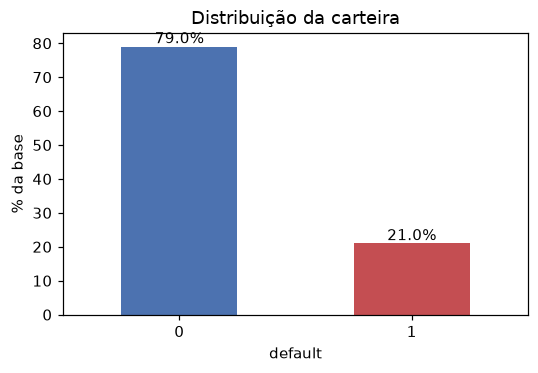

default
0    0.79025
1    0.20975
Name: proporcao, dtype: float64

In [2]:
proporcao = df['default'].value_counts(normalize=True).rename('proporcao')

fig, ax = plt.subplots(figsize=(5, 3.5))
(proporcao * 100).plot(kind='bar', ax=ax, color=['#4c72b0', '#c44e52'])
ax.set_title('Distribuição da carteira')
ax.set_xlabel('default'); ax.set_ylabel('% da base')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(proporcao * 100):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.tight_layout(); plt.show()

proporcao

A classe positiva (default) é minoritária (~20%). Isso justifica **SMOTE** no treino e o uso de métricas como PR-AUC/recall em vez de acurácia.

## Default por segmento

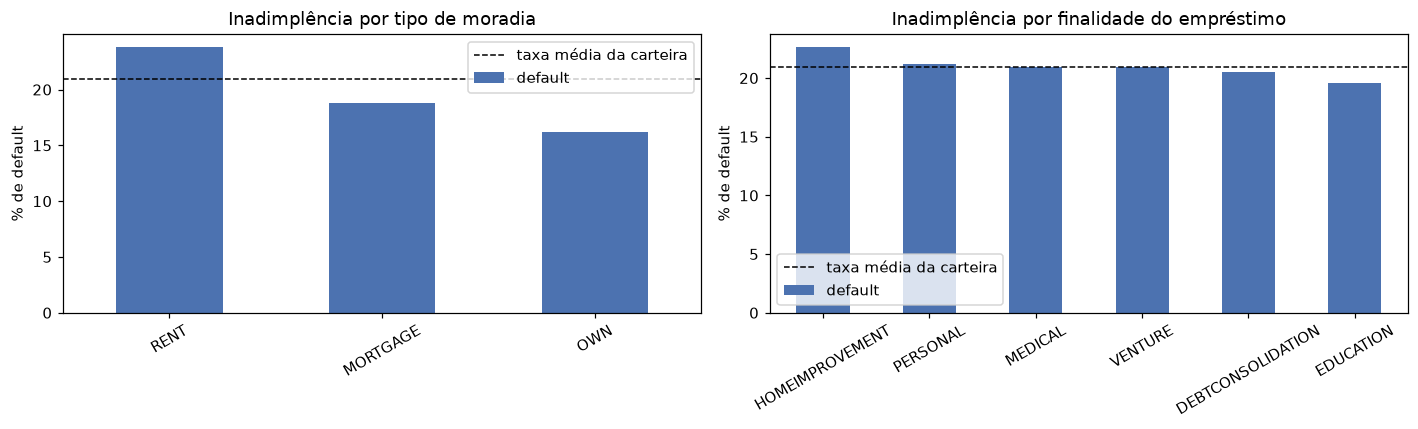

home_ownership
RENT        23.78
MORTGAGE    18.80
OWN         16.21
Name: default, dtype: float64

loan_intent
HOMEIMPROVEMENT      22.61
PERSONAL             21.20
MEDICAL              20.98
VENTURE              20.90
DEBTCONSOLIDATION    20.51
EDUCATION            19.61
Name: default, dtype: float64

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
taxa_media = df['default'].mean() * 100

for eixo, col, titulo in [(ax[0], 'home_ownership', 'Tipo de moradia'),
                          (ax[1], 'loan_intent', 'Finalidade do empréstimo')]:
    serie = (df.groupby(col)['default'].mean() * 100).sort_values(ascending=False)
    serie.plot(kind='bar', ax=eixo, color='#4c72b0')
    eixo.axhline(taxa_media, ls='--', c='k', lw=1, label='taxa média da carteira')
    eixo.set_title(f'Inadimplência por {titulo.lower()}')
    eixo.set_xlabel(''); eixo.set_ylabel('% de default'); eixo.legend()
    eixo.tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()

for col in ['home_ownership', 'loan_intent']:
    display((df.groupby(col)['default'].mean() * 100).sort_values(ascending=False).round(2))

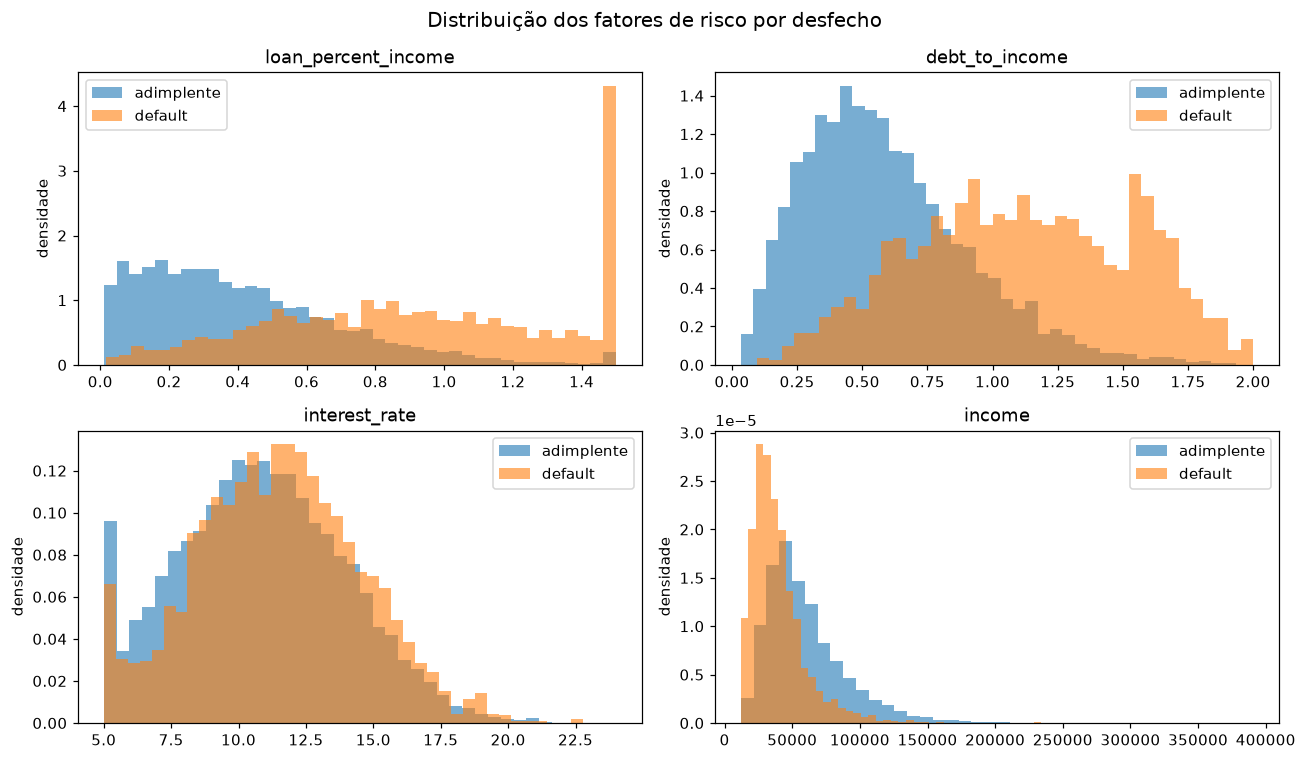

,loan_percent_income,debt_to_income,interest_rate,income
default,,,,
0,0.350,0.543,10.79,52988.0
1,0.903,1.115,11.47,34770.0


In [4]:
# Como os principais fatores de risco se distribuem em cada grupo.
# Densidade normalizada: o grupo de default é ~4x menor, então contagem enganaria.
drivers = ['loan_percent_income', 'debt_to_income', 'interest_rate', 'income']

fig, axs = plt.subplots(2, 2, figsize=(12, 7))
for eixo, col in zip(axs.ravel(), drivers):
    eixo.hist(df.loc[df['default'] == 0, col], bins=40, density=True, alpha=0.6, label='adimplente')
    eixo.hist(df.loc[df['default'] == 1, col], bins=40, density=True, alpha=0.6, label='default')
    eixo.set_title(col); eixo.set_ylabel('densidade'); eixo.legend()

fig.suptitle('Distribuição dos fatores de risco por desfecho', fontsize=13)
plt.tight_layout(); plt.show()

df.groupby('default')[drivers].median().round(3)

## Correlação das variáveis numéricas com o default

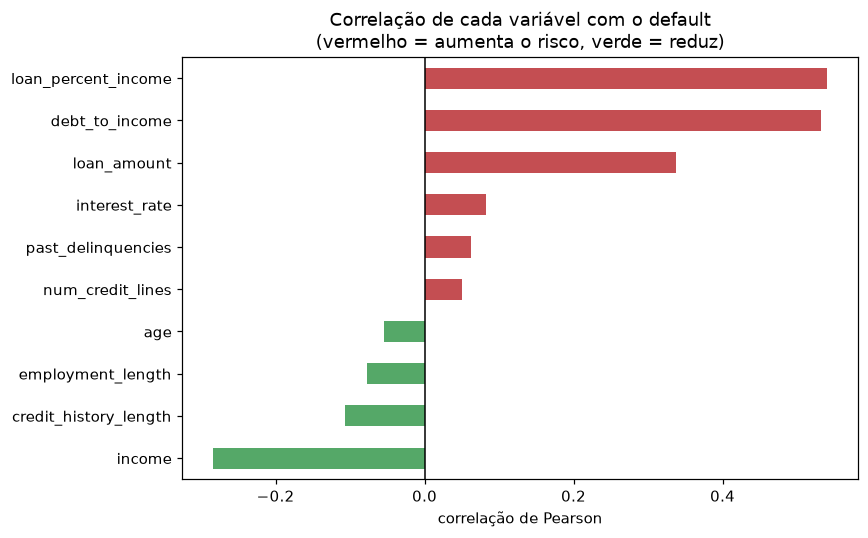

loan_percent_income      0.541
debt_to_income           0.532
loan_amount              0.338
interest_rate            0.082
past_delinquencies       0.063
num_credit_lines         0.050
age                     -0.055
employment_length       -0.077
credit_history_length   -0.106
income                  -0.284
Name: default, dtype: float64

In [5]:
num = df.select_dtypes('number')
corr = num.corr()['default'].drop('default').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
cores = ['#55a868' if v < 0 else '#c44e52' for v in corr]
corr.plot(kind='barh', ax=ax, color=cores)
ax.axvline(0, c='k', lw=1)
ax.set_title('Correlação de cada variável com o default\n(vermelho = aumenta o risco, verde = reduz)')
ax.set_xlabel('correlação de Pearson')
plt.tight_layout(); plt.show()

corr.sort_values(ascending=False).round(3)

,clientes,taxa_default
past_delinquencies,,
0,8075,19.46
1,3157,23.00
2,678,28.32
3,84,28.57
4,6,66.67


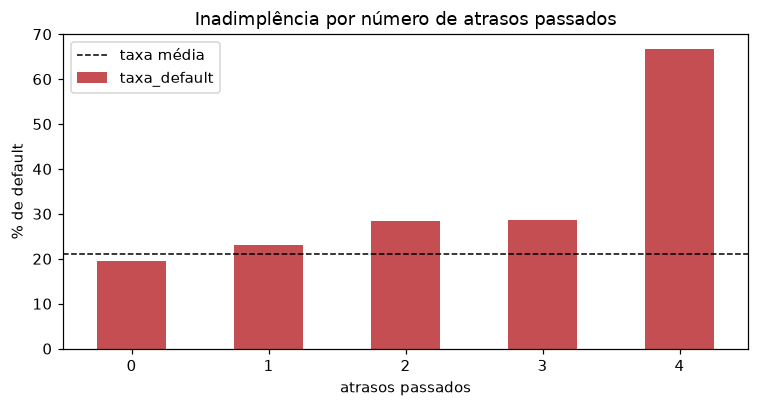

In [6]:
# A correlação de Pearson de `past_delinquencies` ficou baixa (0,06), o que
# contraria a intuição de crédito. Antes de descartar a variável: Pearson mede
# relação LINEAR, e aqui trata-se de uma contagem concentrada em zero.
# Olhando a taxa de default por número de atrasos:
por_atraso = df.groupby('past_delinquencies').agg(
    clientes=('default', 'size'),
    taxa_default=('default', lambda s: round(s.mean() * 100, 2)),
)
display(por_atraso)

fig, ax = plt.subplots(figsize=(7, 3.8))
por_atraso['taxa_default'].plot(kind='bar', ax=ax, color='#c44e52')
ax.axhline(df['default'].mean() * 100, ls='--', c='k', lw=1, label='taxa média')
ax.set_title('Inadimplência por número de atrasos passados')
ax.set_xlabel('atrasos passados'); ax.set_ylabel('% de default')
ax.tick_params(axis='x', rotation=0); ax.legend()
plt.tight_layout(); plt.show()

### Insights de negócio

Carteira com **20,98% de default** — desbalanceada, o que justifica **SMOTE só no
treino** e métricas de PR-AUC/KS/recall em vez de acurácia.

**Os dois fatores que dominam** são de capacidade de pagamento, e com folga:

| Variável | Correlação com default | Mediana adimplente | Mediana em default |
|---|---:|---:|---:|
| `loan_percent_income` (parcela/renda) | **+0,541** | 0,350 | 0,903 |
| `debt_to_income` (endividamento) | **+0,532** | 0,543 | 1,115 |
| `loan_amount` | +0,338 | — | — |
| `income` | **−0,284** | R$ 52.988 | R$ 34.770 |
| `credit_history_length` | −0,106 | — | — |

Quem entra em default compromete **quase toda a renda com a parcela** (mediana de
0,90 contra 0,35) e já deve **mais de uma renda** (1,12 contra 0,54). É o sinal
mais limpo da base.

**Moradia separa bem:** aluguel **23,78%** de default contra **16,21%** de quem tem
imóvel próprio — quase 1,5× de diferença.

**Duas correções ao que a intuição sugeria:**

1. **`past_delinquencies` não é o fator dominante que se esperaria.** A correlação
   de Pearson deu apenas **0,063**, mas isso subestima: é uma contagem concentrada
   em zero e o efeito não é linear. Olhando por faixa, a relação é **monótona e
   real** — 19,46% (sem atrasos) → 23,00% (1) → 28,32% (2) → 28,57% (3). O efeito
   existe e vale como feature (daí a flag `has_delinquency`), mas é **moderado**,
   não dominante. Descartar pela correlação teria sido um erro; chamá-lo de fator
   principal também.
2. **A finalidade do empréstimo quase não discrimina.** A taxa vai de **19,61%**
   (educação) a **22,61%** (reforma) — 3 pontos de amplitude, contra 7,6 pontos da
   moradia. É uma variável fraca aqui e não deve receber peso na narrativa de
   risco só por ser intuitiva.

**O que isso define para a Etapa 4 (feature engineering):** as features derivadas
priorizam capacidade de pagamento — `installment_pressure` (juros × comprometimento
de renda) e `income_per_credit_line` — em vez de apostar em histórico de atraso.
Os pesos são confirmados depois pelo SHAP na Etapa 5.